## Entendimiento del contexto 

Un call center es un departamento o empresa que se encarga de gestionar llamadas teléfonicas entre una organización y sus clientes, principalmente trabaja con el canal telefónico.

Su ayuda se centra en mejorar la atención al cliente, aumentar ventas, resolver problemas rápidamente y mantener contacto constante con los clientes. Fuente https://www.merriam-webster.com/dictionary/call%20center?utm_source=chatgpt.com 

La calidad en el servicio al cliente es un factor diferenciador para las empresas cada interacción telefónica puede ser decisiva, las métricas para medir la calidad de servicio en llamadas traduce experiencia del cliente en datos concretos y accionables. 

Métricas claves como el tiempo promedio de respuesta, indice de satisfacción del cliente y frecuencia de llamadas repetidas ofrecen pistas sobre la calidad de las soluciones proporcionadas. 

Los datos brutos se convierten en historias reveladoras que descubren patrones de comportamiento y áreas de mejoras tangibles; adicional guian a los empresarios a tomar decisiones estratégicas para tener éxito en la atención telefónica. Fuente https://www.centrosdellamadas.com/metricas-clave-para-medir-calidad-de-servicio-en-llamadas/#:~:text=En%20el%20competitivo%20mundo%20del%20servicio%20al,servicio%20de%20atenci%C3%B3n%20telef%C3%B3nica%20de%20alta%20calidad.

La empresa de servicio de telefonía virtual CallMeMaybe ha solicitado mi ayuda como analista de datos; para identificar operadores ineficaces esos que tienen gran cantidad de llamadas perdidas (internas y externas), tiempo de espera prolongado en llamadas entrantes y número reducido de llamadas salientes. Los clientes de la empresa CallMeMaybe son organizaciones que necesitan distribuir gran cantidad de llamadas entrantes entre varios operadores, o realizar llamadas salientes a través de sus operadores.

## Entendimiento de los datos 

La empresa de servicio de telefonía virtual ha compartido los datasets que continene información sobre el uso del servicio.

El dataset telecom_dataset_us.csv contiene las siguientes columnas:
* user_id: ID de la cuenta de cliente
* date: fecha en la que se recuperaron las estadísticas
* direction: "dirección" de llamada (out para saliente, in para entrante)
* internal: si la llamada fue interna (entre los operadores de un cliente o clienta)
* operator_id: identificador del operador
* is_missed_call: si fue una llamada perdida
* calls_count: número de llamadas
* call_duration: duración de la llamada (sin incluir el tiempo de espera)
* total_call_duration: duración de la llamada (incluido el tiempo de espera)

El conjunto de datos telecom_clients_us.csv tiene las siguientes columnas:
* user_id: ID de usuario/a
* tariff_plan: tarifa actual de la clientela
* date_start: fecha de registro de la clientela

In [1]:
# Cargar las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import plotly.graph_objects as go

In [2]:
# Cargas los datasets 
df_operadores = pd.read_csv("telecom_dataset_new.csv")
df_clientes = pd.read_csv("telecom_clients.csv")

In [3]:
def fun_diagnostico (df):
    print("ESTRUCTURA GENERAL DE LA TABLA:")
    print(df.info())
    print("\n")
    print("MUESTRA DE LOS DATOS: ")
    print(df.sample(5))
    print("\n")
    print(f"FILAS DUPLICADAS: {df.duplicated().sum()}")

In [4]:
fun_diagnostico(df_operadores)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None


MUESTRA DE LOS DATOS: 
       user_id                       date direction internal  operator_id  \
347     166377  2019-10-14 00:00:00+03:00       out    False     880028.0   
2822    166482  2019-08-22 00:00:00+03:00        in    

In [5]:
fun_diagnostico(df_clientes)

ESTRUCTURA GENERAL DE LA TABLA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None


MUESTRA DE LOS DATOS: 
     user_id tariff_plan  date_start
99    168088           C  2019-10-14
569   167947           B  2019-10-07
617   166970           B  2019-08-27
588   167445           B  2019-09-17
317   167242           C  2019-09-09


FILAS DUPLICADAS: 0


## Análisis exploratorio de los datos 

In [6]:
# Registros faltantes en columna operador_id
registro_sin_operador = df_operadores["operator_id"].isna().sum()
total_registros = len(df_operadores)
porcentaje_sin_operador = (registro_sin_operador / total_registros) * 100

print(f"Total de registros sin operador_id: {registro_sin_operador}")
print(f"Porcentaje registros sin operador: {porcentaje_sin_operador:.2f}%")

Total de registros sin operador_id: 8172
Porcentaje registros sin operador: 15.16%


In [7]:
# Faltantes en llamadas internas
internas_nan = df_operadores["internal"].isna().sum()
print(f"Total de llamadas internas sin registro: {internas_nan}")

Total de llamadas internas sin registro: 117


In [8]:
operadores_unicos = df_operadores['operator_id'].nunique()
print(f"Total de operados: {operadores_unicos}")

Total de operados: 1092


## Estructura de los datos 

* El dataset de operadores contiene toda la información con respecto a la operación realizada durante 4 meses del año 2019.
* Cuenta con 53902 registros los cuales se dividen entres llamadas entrantes, salientes, perdidas e internas.
* La empresa de telefonía cuenta con 1092 operadores al momento de recibir la información para su respectivo análisis.
* Se evidencian 8172 registros con valores faltantes principalmente en la asignación de operador.  

## Plan de acción para prepración de datos

*  El DataFrame de operadores:
    * Convertir la columna date al formato datetime.  
    * Los valores faltantes de columna operator_id eliminarlos.
    * Columna operador_id cambiar de tipo flotante a entero.
    * Registros con valores faltantes en columna internal proceder a eliminar, no se podría validar si es llamada interna o externa. 
    * Adicionar columna tiempo_espera correspondiente a la diferencia entre total_call_duration y call_duration.
    * Crear una tabla con los operadores por llamadas e identificar promedio de cada en orden ascendente.
    * Crear un dashborad con las métricas evaluadas.
    * Informe en formato PDF para los stakeholders supervisores el resultado brindará información para identificar los operadores menos eficaces y reportar al área de recursos humanos qienes toman decisiones de continuar o no con el operador.
    * Tiempo estimados 3 días desarrolando plan de acción, 2 día crear dashboard, 1 día informe para los stakeholders.

## Métricas principales

* Tasa de llamadas perdidas por operador por mes tasa_perdidas = llamadas perdidas / total llamadas.
* Tasa de llamadas entrantes y salientes por operador. 
* Tiempo de espera prolongado por operador cada mes tiempo_promedio_espera = tiempo_espera / total_llamadas.
    
    * Estos resultados permitirán identificar los valores para clasificar a los operadores en eficaces o ineficaces. 

## Hipótesis a validar 

* H0: No existen diferencias significativas en métricas de desempeño entre operadores.
* H1: Existen operadores con métricas significativamente inferiores al promedio del equipo.

## Preparación de los datos

In [9]:
# Convertir la columna date al formato datetime y extraer el mes
df_operadores['date'] = pd.to_datetime(df_operadores['date'])
df_operadores['month'] = df_operadores['date'].dt.month
print(df_operadores['date'].dtypes)
df_operadores.sample(5)

datetime64[ns, pytz.FixedOffset(180)]


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month
4610,166511,2019-09-25 00:00:00+03:00,out,False,891416.0,False,18,2312,2473,9
23962,167109,2019-10-07 00:00:00+03:00,out,True,907182.0,True,1,0,13,10
50667,168252,2019-11-20 00:00:00+03:00,out,False,940616.0,False,103,3550,5247,11
4745,166511,2019-10-09 00:00:00+03:00,in,False,NaN,True,4,0,101,10
13537,166782,2019-11-28 00:00:00+03:00,in,False,NaN,False,1,135,158,11


In [10]:
# Los valores faltantes de columna operator_id eliminarlos.
df_operadores = df_operadores.dropna(subset=['operator_id'])
df_operadores['operator_id'].isna().sum()


0

In [11]:
# Registros con valores faltantes en columna internal proceder a eliminar, no se podría validar si es llamada interna o externa. 
df_operadores = df_operadores.dropna(subset=['internal'])
df_operadores.reset_index(drop=True, inplace=True)
df_operadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45670 entries, 0 to 45669
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              45670 non-null  int64                                
 1   date                 45670 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            45670 non-null  object                               
 3   internal             45670 non-null  object                               
 4   operator_id          45670 non-null  float64                              
 5   is_missed_call       45670 non-null  bool                                 
 6   calls_count          45670 non-null  int64                                
 7   call_duration        45670 non-null  int64                                
 8   total_call_duration  45670 non-null  int64                                
 9   month 

In [12]:
# Adicionar columna tiempo_espera correspondiente a la diferencia entre total_call_duration y call_duration.
df_operadores['tiempo_espera'] = (
    df_operadores['total_call_duration'] - df_operadores['call_duration']
)
df_operadores[['call_duration', 'total_call_duration', 'tiempo_espera']].head()

,call_duration,total_call_duration,tiempo_espera
0,0,5,5
1,0,1,1
2,10,18,8
3,0,25,25
4,3,29,26


## Métricas

* Tasa de llamadas perdidas por operador por mes

In [13]:
# Filtrar llamadas perdidas 
df_missed = df_operadores[df_operadores['is_missed_call'] == True]

In [14]:
# Total de llamadas por operador por mes
total_calls = df_operadores.groupby(
    ['operator_id', 'month']
)['calls_count'].sum().reset_index(name='total_calls')

# Total de llamadas perdidas por operador por mes 
missed_calls = df_missed.groupby(
    ['operator_id', 'month']
)['calls_count'].sum().reset_index(name='missed_calls')


In [15]:
# Calcular tasa de llamadas perdidas
df_rate_missed = total_calls.merge(
    missed_calls,
    on=['operator_id', 'month'],
    how='left'
)
df_rate_missed['missed_calls'] = df_rate_missed['missed_calls'].fillna(0)

df_rate_missed['missed_rate'] = (
    df_rate_missed['missed_calls'] / df_rate_missed['total_calls']
)

df_rate_missed.sort_values('missed_rate', ascending=False).head(5)

,operator_id,month,total_calls,missed_calls,missed_rate
1520,936296.0,10,3,3.0,1.0
1521,936296.0,11,1,1.0,1.0
1535,937366.0,10,1,1.0,1.0
1540,937370.0,11,2,2.0,1.0
1555,937650.0,11,1,1.0,1.0


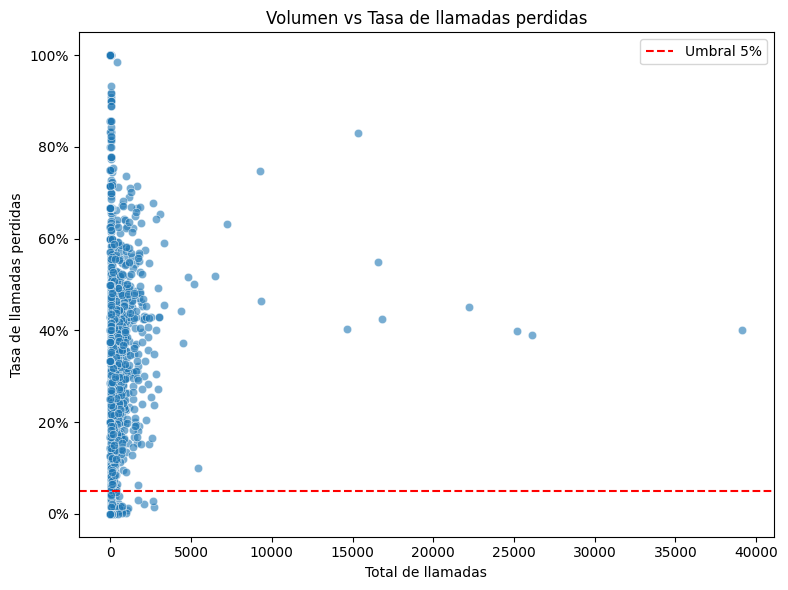

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_rate_missed,
    x="total_calls",
    y="missed_rate",
    alpha=0.6
)

plt.axhline(0.05, linestyle="--", color="red", label="Umbral 5%")
plt.ylabel("Tasa de llamadas perdidas")
plt.xlabel("Total de llamadas")
plt.title("Volumen vs Tasa de llamadas perdidas")

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusión 

* El gráfico representa a un operador en un mes específico. 
* Los casos más criticos se concentran en operadores con más de 300 llamadas mensuales.
* La tasa de llamadas perdidas es moderadamente alta en muchos casos, la concentración porcentual de llamadas perdidas esta entre 15% y 70% lo que sugiere que el desempeño general de los operadores no es óptimo. 
* Los operadores aislados, se puede interpretar como operadores críticos. de riesgo operativo.

* Tasa de llamadas entrantes y salientes por operador.

In [17]:
df_direction = (
    df_operadores
    .groupby(['operator_id', 'month', 'direction'])['calls_count']
    .sum()
    .unstack(fill_value=0)  
    .reset_index()
)
df_direction['total_calls'] = df_direction['in'] + df_direction['out']

df_direction['in_rate'] = df_direction['in'] / df_direction['total_calls']
df_direction['out_rate'] = df_direction['out'] / df_direction['total_calls']
df_direction.sample(5)

direction,operator_id,month,in,out,total_calls,in_rate,out_rate
224,891252.0,8,0,85,85,0.000000,1.000000
675,905542.0,9,36,514,550,0.065455,0.934545
2110,971102.0,11,78,0,78,1.000000,0.000000
1614,937900.0,11,0,4,4,0.000000,1.000000
440,898676.0,10,3,0,3,1.000000,0.000000


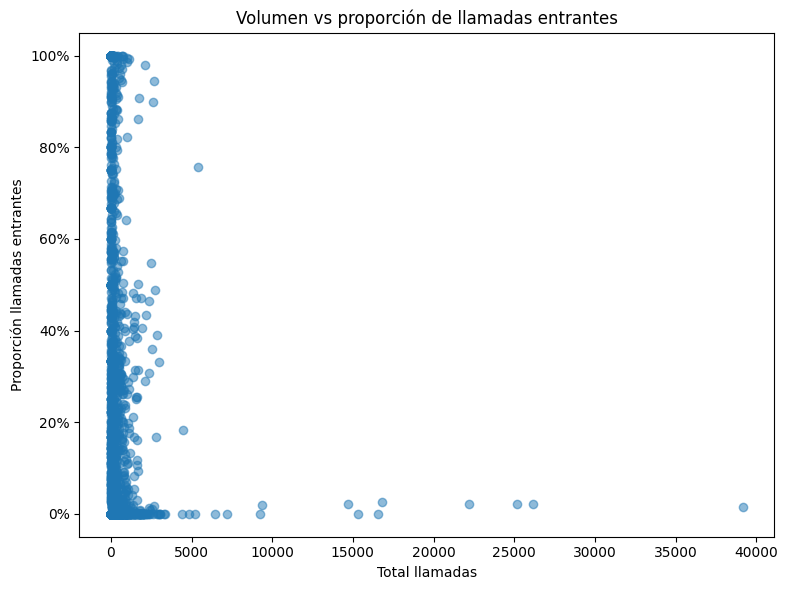

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_direction["total_calls"],
    df_direction["in_rate"],
    alpha=0.5
)

plt.ylabel("Proporción llamadas entrantes")
plt.xlabel("Total llamadas")
plt.title("Volumen vs proporción de llamadas entrantes")

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
plt.tight_layout()
plt.show()

# Conclusión 
* La mayoría de los operadores tienen bajo porcentaje de llamadas entrantes, es de aclarar que la operación principal de la empresa de telefonía es distribuir gran cantidad de llamadas entrantes entre varios operadores. El tráfico de las llamadas entrantes no es dominante de acuerdo a los resultados obtenidos. 

* Tiempo promedio de espera por operador por mes

In [19]:
df_operadores['tiempo_espera'] = (
    df_operadores['total_call_duration'] - df_operadores['call_duration']
)

df_waiting_time = (
    df_operadores
    .groupby(['operator_id', 'month'])
    .agg({
        'tiempo_espera': 'sum',
        'calls_count': 'sum'
    })
    .reset_index()
)

df_waiting_time['avg_wait_time'] = (
    df_waiting_time['tiempo_espera'] / df_waiting_time['calls_count']
)
df_waiting_time.sample(5)

,operator_id,month,tiempo_espera,calls_count,avg_wait_time
541,901034.0,11,186,13,14.307692
2112,972408.0,11,75,8,9.375000
1391,930020.0,10,8297,392,21.165816
166,890406.0,11,6823,475,14.364211
1151,919792.0,9,2080,74,28.108108


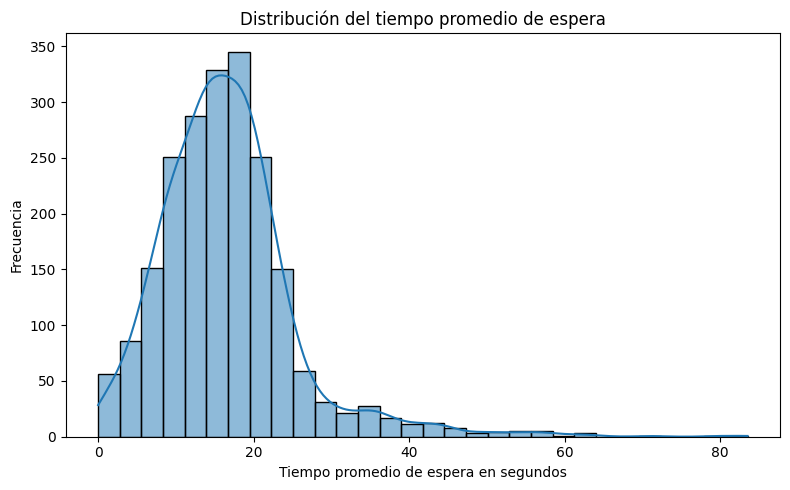

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_waiting_time["avg_wait_time"],
    bins=30,
    kde=True
)

plt.title("Distribución del tiempo promedio de espera")
plt.xlabel("Tiempo promedio de espera en segundos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Conclusión 

* El tiempo promedio de espera oscila entre en valores bajos, lo que indica que la maypría de operadores maneja las llamadas sin generar demoras críticas. 

In [21]:
summary_wait = (
    df_waiting_time
    .groupby("operator_id")["avg_wait_time"]
    .mean()
    .reset_index()
    .sort_values("avg_wait_time", ascending=False)
)

top10_wait = summary_wait.head(10)

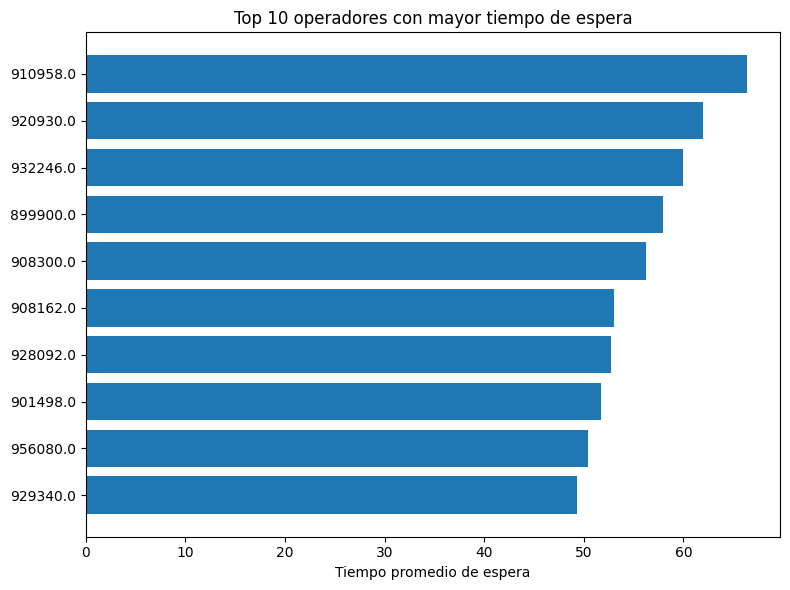

In [22]:
plt.figure(figsize=(8,6))
plt.barh(
    top10_wait["operator_id"].astype(str),
    top10_wait["avg_wait_time"]
)

plt.xlabel("Tiempo promedio de espera")
plt.title("Top 10 operadores con mayor tiempo de espera")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Unir las métricas en un DataFrame
df_final = df_rate_missed.merge(
    df_direction,
    on=['operator_id', 'month'],
    how='left'
)

df_final = df_final.merge(
    df_waiting_time[['operator_id', 'month', 'avg_wait_time']],
    on=['operator_id', 'month'],
    how='left'
)

df_final.sample(5)

,operator_id,month,total_calls_x,missed_calls,missed_rate,in,out,total_calls_y,in_rate,out_rate,avg_wait_time
890,910902.0,11,11,0.0,0.000000,0,11,11,0.000000,1.000000,13.272727
847,909502.0,9,564,222.0,0.393617,0,564,564,0.000000,1.000000,20.911348
1153,919792.0,11,372,6.0,0.016129,340,32,372,0.913978,0.086022,28.623656
127,888540.0,10,14,5.0,0.357143,2,12,14,0.142857,0.857143,14.500000
156,890402.0,9,510,127.0,0.249020,143,367,510,0.280392,0.719608,15.447059


In [24]:
df_final.rename(columns={'total_calls_x': 'total_calls'}, inplace=True)
df_final.drop(columns=['total_calls_y'], inplace=True)
print(df_final.columns)

Index(['operator_id', 'month', 'total_calls', 'missed_calls', 'missed_rate',
       'in', 'out', 'in_rate', 'out_rate', 'avg_wait_time'],
      dtype='object')


In [25]:
# Crear grupos por operador
grupos = [
    grupo["missed_rate"].values
    for _, grupo in df_rate_missed.groupby("operator_id")
]

f_stat, p_value = stats.f_oneway(*grupos)

alpha = 0.05

print("F-statistic:", round(f_stat, 4))
print("p-value:", p_value)

if p_value < alpha:
    print("\nResultado: Se RECHAZA la hipótesis nula.")
    print("Conclusión: Existen diferencias significativas entre operadores.")
else:
    print("\nResultado: NO se rechaza la hipótesis nula.")
    print("Conclusión: No se encontraron diferencias significativas entre operadores.")

F-statistic: 3.2387
p-value: 1.2549307818528032e-76

Resultado: Se RECHAZA la hipótesis nula.
Conclusión: Existen diferencias significativas entre operadores.


## Conclusión 

* Con un nivel de significancia del 5%, un p-value inferior a 0.05, lo que permite rechazar la hipótesis nula y confirmar que existen diferencias estadísticamente significativas en el desempeño entre operadores.

## índice de ineficacia

Con el objetivo de identificar operadores con desempeño crítico, se definieron tres indicadores operativos clave. Un operador es clasificado como ineficaz cuando cumple al menos dos de las siguientes condiciones:

* Alta tasa de llamadas perdidas >10% 
* Tiempo prolongado de espera superior a >30 segundos
* Baja proporción de llamadas salientes <30%

In [26]:
# Promediar métricas por operador 
df_modelo = df_final.groupby('operator_id')[
    ['missed_rate', 'avg_wait_time', 'out_rate']
].mean().reset_index()
df_modelo.sample(5)

,operator_id,missed_rate,avg_wait_time,out_rate
1039,962658.0,0.155288,11.618474,0.496653
773,940474.0,0.708333,7.666667,1.000000
411,917852.0,0.199793,13.192069,0.732445
562,927912.0,0.058824,2.705882,0.000000
885,947598.0,0.491870,16.626016,1.000000


In [27]:
# Definir umbrales específicos
umbral_missed = 0.10  
umbral_wait_time = 30  
umbral_out_rate = 0.30  

# Crear variables binarias para cada condición
df_modelo['alta_perdida'] = df_modelo['missed_rate'] > umbral_missed
df_modelo['alto_tiempo_espera'] = df_modelo['avg_wait_time'] > umbral_wait_time  
df_modelo['baja_salida'] = df_modelo['out_rate'] < umbral_out_rate

# Contar cuántas condiciones cumple cada operador
df_modelo['condiciones_cumplidas'] = (
    df_modelo['alta_perdida'].astype(int) + 
    df_modelo['alto_tiempo_espera'].astype(int) + 
    df_modelo['baja_salida'].astype(int)
)

# Clasificar como ineficaz si cumple 2 o más condiciones
df_modelo['ineficaz'] = df_modelo['condiciones_cumplidas'] >= 2

In [28]:
# Análisis final de resultados
print("RESUMEN EJECUTIVO")
total_operadores = len(df_modelo)
operadores_ineficaces = df_modelo['ineficaz'].sum()

print(f"Total operadores analizados: {total_operadores}")
print(f"Operadores ineficaces identificados: {operadores_ineficaces}")
print(f"Porcentaje de ineficacia: {operadores_ineficaces/total_operadores*100:.1f}%")

# Top 10 más críticos
print("TOP 10 OPERADORES MÁS CRÍTICOS")
criticos = df_modelo[df_modelo['ineficaz'] == True].sort_values('condiciones_cumplidas', ascending=False)
print(criticos[['operator_id', 'missed_rate', 'avg_wait_time', 'out_rate', 'condiciones_cumplidas']].head(10))


RESUMEN EJECUTIVO
Total operadores analizados: 1092
Operadores ineficaces identificados: 78
Porcentaje de ineficacia: 7.1%
TOP 10 OPERADORES MÁS CRÍTICOS
     operator_id  missed_rate  avg_wait_time  out_rate  condiciones_cumplidas
109     894120.0     0.125000      35.525000      0.00                      3
8       882476.0     0.000000      31.666667      0.00                      2
559     927142.0     0.166667       4.333333      0.25                      2
650     934432.0     0.000000      34.687500      0.00                      2
645     934188.0     0.125000      15.625000      0.25                      2
643     934098.0     0.375000      26.375000      0.00                      2
617     932246.0     1.000000      60.000000      1.00                      2
592     930242.0     0.166667      16.500000      0.00                      2
580     929340.0     0.000000      49.357143      0.00                      2
565     928092.0     0.000000      52.750000      0.00            

In [29]:
# Análisis detallado por tipo de problema
print("ANÁLISIS DETALLADO POR CONDICIONES")
ineficaces = df_modelo[df_modelo['ineficaz'] == True]

# Distribución por condiciones
condiciones_dist = ineficaces['condiciones_cumplidas'].value_counts().sort_index()
print("Distribución por número de condiciones:")
for cond, count in condiciones_dist.items():
    print(f"  {cond} condiciones: {count} operadores ({count/len(ineficaces)*100:.1f}%)")

# Análisis por tipo de problema específico
print("PROBLEMAS MÁS FRECUENTES")
print(f"Alta tasa de pérdida (>10%): {df_modelo['alta_perdida'].sum()} operadores")
print(f"Alto tiempo de espera (>30s): {df_modelo['alto_tiempo_espera'].sum()} operadores")
print(f"Baja tasa saliente (<30%): {df_modelo['baja_salida'].sum()} operadores")


ANÁLISIS DETALLADO POR CONDICIONES
Distribución por número de condiciones:
  2 condiciones: 77 operadores (98.7%)
  3 condiciones: 1 operadores (1.3%)
PROBLEMAS MÁS FRECUENTES
Alta tasa de pérdida (>10%): 782 operadores
Alto tiempo de espera (>30s): 55 operadores
Baja tasa saliente (<30%): 281 operadores


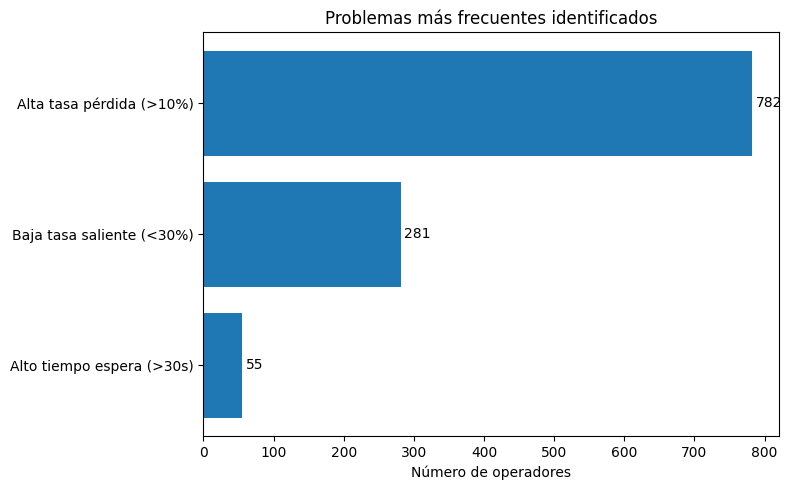

In [30]:
df_modelo['alta_perdida'].sum()
df_modelo['alto_tiempo_espera'].sum()
df_modelo['baja_salida'].sum()

problemas = {
    "Alta tasa pérdida (>10%)": df_modelo['alta_perdida'].sum(),
    "Alto tiempo espera (>30s)": df_modelo['alto_tiempo_espera'].sum(),
    "Baja tasa saliente (<30%)": df_modelo['baja_salida'].sum()
}

# Convertir a DataFrame para poder ordenar
df_problemas = (
    pd.DataFrame(list(problemas.items()), columns=["Problema", "Cantidad"])
    .sort_values("Cantidad", ascending=True) 
)

plt.figure(figsize=(8,5))

bars = plt.barh(
    df_problemas["Problema"],
    df_problemas["Cantidad"]
)

plt.xlabel("Número de operadores")
plt.title("Problemas más frecuentes identificados")

# Etiquetas
for i, v in enumerate(df_problemas["Cantidad"]):
    plt.text(v + 5, i, str(v), va='center')

plt.tight_layout()
plt.show()

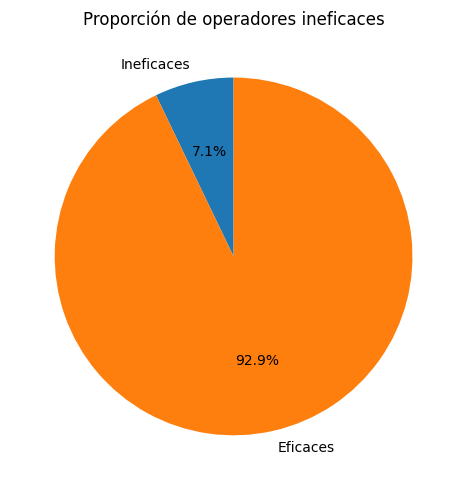

In [31]:
total_operadores = len(df_modelo)
operadores_ineficaces = df_modelo['ineficaz'].sum()

plt.figure(figsize=(5,5))

plt.pie(
    [operadores_ineficaces, total_operadores - operadores_ineficaces],
    labels=["Ineficaces", "Eficaces"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporción de operadores ineficaces")
plt.tight_layout()
plt.show()